In [7]:
import os
import sys
import json
import random
import copy
from enum import Enum
from google.colab import drive, userdata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve
import torchvision.transforms as transforms
from google.colab import runtime

print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA disponible: True


In [3]:
# Celda 1 — Setup
drive.mount('/content/drive')
!rm -rf /content/ThoraxNet
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/cuellojoaquinn/ThoraxNet.git /content/ThoraxNet

Mounted at /content/drive
Cloning into '/content/ThoraxNet'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 290 (delta 24), reused 69 (delta 8), pack-reused 201 (from 1)
Receiving objects: 100% (290/290), 37.60 MiB | 12.13 MiB/s, done.
Resolving deltas: 100% (110/110), done.


In [4]:
sys.path.append('/content/ThoraxNet/dev')
DATASET_ROOT = "/content/dataset"
OUTPUT_DIR   = "/content/drive/MyDrive/PF-NN/resultados-final"

In [8]:
!cp /content/drive/MyDrive/chexpert.zip /content/
!unzip -q /content/chexpert.zip -d /content/dataset

In [9]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


# Estrategia de proyeccion

In [10]:
# @title
from enum import Enum

class ProjectionStrategy(Enum):
    """Dirección de incidencia del rayo X sobre el paciente."""
    PA_ONLY = "PA"   # rayo entra por la espalda — paciente parado (ideal)
    AP_ONLY = "AP"   # rayo entra por el pecho  — paciente acostado
    ALL     = "all"


class ViewStrategy(Enum):
    """Plano de adquisición de la imagen."""
    FRONTAL_ONLY = "Frontal"
    LATERAL_ONLY = "Lateral"
    ALL          = "all"


print('ProjectionStrategy:', [e.name for e in ProjectionStrategy])
print('ViewStrategy:      ', [e.name for e in ViewStrategy])

ProjectionStrategy: ['PA_ONLY', 'AP_ONLY', 'ALL']
ViewStrategy:       ['FRONTAL_ONLY', 'LATERAL_ONLY', 'ALL']


# **Clases**

## ChexpertDataset

In [14]:
class UncertaintyStrategy(Enum):
    """Cómo tratar las etiquetas inciertas (-1) de CheXpert."""
    U_ZEROS = "u_zeros"   # -1 → 0
    U_ONES  = "u_ones"    # -1 → 1
    LSR     = "lsr"       # -1 → random en U(α, β)


CHEXPERT_LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture'
]

class CheXpertDataset(Dataset):

    def __init__(
        self,
        root,
        csv_path,
        transform=None,
        projection=ProjectionStrategy.AP_ONLY,
        view=ViewStrategy.FRONTAL_ONLY,
        uncertainty=None,          # ← dict por patología
        lsr_alpha=0.55,
        lsr_beta=0.85,
    ):
        self.root = root
        self.transform = transform
        self.lsr_alpha = lsr_alpha
        self.lsr_beta = lsr_beta

        # Si no se pasa dict, todas usan LSR por defecto
        if uncertainty is None:
            self.uncertainty = {
                label: UncertaintyStrategy.LSR
                for label in CHEXPERT_LABELS
            }
        else:
            self.uncertainty = uncertainty

        df = pd.read_csv(csv_path)
        self.df = self._filter_view(df, view)
        self.df = self._filter_projection(self.df, projection)

    def _filter_view(self, df, strategy):
        if strategy == ViewStrategy.ALL:
            return df
        return df[df['Frontal/Lateral'] == strategy.value].reset_index(drop=True)

    def _filter_projection(self, df, strategy):
        if strategy == ProjectionStrategy.ALL:
            return df
        return df[df['AP/PA'] == strategy.value].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = self._load_image(row)
        except Exception:
            return self.__getitem__(idx + 1)
        return image, self._extract_labels(row)

    def _load_image(self, row):
        img = Image.open(os.path.join(self.root, row['Path'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

    def _extract_labels(self, row):
        labels = {}
        for label in CHEXPERT_LABELS:
            value = row[label]
            if pd.isna(value):
                labels[label] = 0
            elif int(value) == -1:
                strategy = self.uncertainty[label]
                if strategy == UncertaintyStrategy.U_ZEROS:
                    labels[label] = 0
                elif strategy == UncertaintyStrategy.U_ONES:
                    labels[label] = 1
                else:  # LSR
                    labels[label] = np.random.uniform(
                        self.lsr_alpha, self.lsr_beta
                    )
            else:
                labels[label] = int(value)
        return labels

## UnifiedDataset

In [15]:
# @title
CANONICAL_LABELS = [
    'No_Finding', 'Enlarged_Cardiomediastinum', 'Cardiomegaly',
    'Lung_Opacity', 'Lung_Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Effusion',
    'Pleural_Other', 'Fracture',
]

CHEXPERT_TO_CANONICAL = {
    'No Finding':                'No_Finding',
    'Enlarged Cardiomediastinum': 'Enlarged_Cardiomediastinum',
    'Cardiomegaly':              'Cardiomegaly',
    'Lung Opacity':              'Lung_Opacity',
    'Lung Lesion':               'Lung_Lesion',
    'Edema':                     'Edema',
    'Consolidation':             'Consolidation',
    'Pneumonia':                 'Pneumonia',
    'Atelectasis':               'Atelectasis',
    'Pneumothorax':              'Pneumothorax',
    'Pleural Effusion':          'Effusion',
    'Pleural Other':             'Pleural_Other',
    'Fracture':                  'Fracture',
}

CX8_TO_CANONICAL = {
    'No Finding':    'No_Finding',
    'Atelectasis':   'Atelectasis',
    'Consolidation': 'Consolidation',
    'Pneumothorax':  'Pneumothorax',
    'Edema':         'Edema',
    'Effusion':      'Effusion',
    'Pneumonia':     'Pneumonia',
    'Cardiomegaly':  'Cardiomegaly',
}

VIN_TO_CANONICAL = {
    'No finding':       'No_Finding',
    'Atelectasis':      'Atelectasis',
    'Cardiomegaly':     'Cardiomegaly',
    'Consolidation':    'Consolidation',
    'Pleural effusion': 'Effusion',
    'Pneumothorax':     'Pneumothorax',
}


class UnifiedDataset(Dataset):

    _MAPPINGS = {
        'chexpert':     CHEXPERT_TO_CANONICAL,
        'chexpert_val': CHEXPERT_TO_CANONICAL,
        'cx8':          CX8_TO_CANONICAL,
        'vin':          VIN_TO_CANONICAL,
    }

    # Se genera solo a partir de los mapeos
    DATASET_EVALUATES = {
        name: set(mapping.values())
        for name, mapping in _MAPPINGS.items()
    }

    def __init__(self, datasets: dict, transform=None):
        self.datasets   = datasets
        self._index_map = [
            (name, i)
            for name, ds in datasets.items()
            for i in range(len(ds))
        ]
        self.transform = transform

    def __len__(self):
        return len(self._index_map)

    def __getitem__(self, idx):
        name, local_idx   = self._index_map[idx]
        image, raw_labels = self.datasets[name][local_idx]
        labels            = self._map_labels(raw_labels, self._MAPPINGS[name])
        labels_tensor     = torch.tensor(
            [labels[l] for l in CANONICAL_LABELS], dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)
        return image, labels_tensor

    def _map_labels(self, raw_labels, mapping):
        canonical = {label: 0 for label in CANONICAL_LABELS}
        for pat, value in raw_labels.items():
            target = mapping.get(pat)
            if target is not None:
                canonical[target] = value
        return canonical

    def class_distribution(self):
        counts = {label: 0 for label in CANONICAL_LABELS}
        for name, ds in self.datasets.items():
            mapping = self._MAPPINGS[name]
            for _, row in ds.df.iterrows():
                labels = ds._extract_labels(row)
                mapped = self._map_labels(labels, mapping)
                for label, value in mapped.items():
                    if value == 1:
                        counts[label] += 1
        return counts

In [16]:
# divide el dataset CheXpert en tres conjuntos (train/val/test)
# asegurándose de que un mismo paciente no aparezca en más de un conjunto. Acá el desglose paso a paso:
def make_chexpert_splits(chexpert_train, chexpert_val, seed=42, ratios=(0.8, 0.1, 0.1)):
    df_train = chexpert_train.df.copy()
    df_val = chexpert_val.df.copy()

    df = pd.concat([df_train, df_val], ignore_index=True)
    df['patient_id'] = df['Path'].apply(lambda x: x.split('/')[-1].split('_')[0])

    patients = np.array(df['patient_id'].unique())
    rng = np.random.default_rng(seed)
    rng.shuffle(patients)

    n = len(patients)
    n_train = int(n * ratios[0])
    n_val = int(n * ratios[1])

    train_patients = set(patients[:n_train])
    val_patients   = set(patients[n_train:n_train + n_val])
    test_patients  = set(patients[n_train + n_val:])

    train_paths = set(df[df['patient_id'].isin(train_patients)]['Path'])
    val_paths   = set(df[df['patient_id'].isin(val_patients)]['Path'])
    test_paths  = set(df[df['patient_id'].isin(test_patients)]['Path'])

    print(f'CheXpert — train: {len(train_paths)} | val: {len(val_paths)} | test: {len(test_paths)}')
    return train_paths, val_paths, test_paths

# Datasets


In [17]:
#Se elige Zeros y Ones a las patologias que el paper demostró que funcionaba mejor.
# mezclar estrategias por patología
# tiene sentido lógico: estás controlando el balance y la fuerza del gradiente independientemente para cada tarea de clasificación
uncertainty_config = {
    'No Finding':                  UncertaintyStrategy.U_ZEROS,
    'Enlarged Cardiomediastinum':  UncertaintyStrategy.U_ONES,
    'Cardiomegaly':                UncertaintyStrategy.U_ONES,
    'Lung Opacity':                UncertaintyStrategy.U_ONES,
    'Lung Lesion':                 UncertaintyStrategy.U_ZEROS,
    'Edema':                       UncertaintyStrategy.U_ONES,   # era LSR
    'Consolidation':               UncertaintyStrategy.U_ONES,   # era LSR
    'Pneumonia':                   UncertaintyStrategy.U_ONES,   # era LSR
    'Atelectasis':                 UncertaintyStrategy.U_ONES,
    'Pneumothorax':                UncertaintyStrategy.U_ZEROS,
    'Pleural Effusion':            UncertaintyStrategy.U_ONES,   # era LSR
    'Pleural Other':               UncertaintyStrategy.U_ZEROS,
    'Fracture':                    UncertaintyStrategy.U_ZEROS,
}

chexpert_train = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'train.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)

chexpert_val = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'valid.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)

### Pruebas de Chexpert: crudo vs mapeado

In [18]:
# Sobre el crudo
for label in CHEXPERT_LABELS:
    count = (chexpert_train.df[label] == -1).sum()
    if count > 0:
        print(f"⚠ {label} todavía tiene {count} valores -1")

print("✓ Chequeo completado")

⚠ Enlarged Cardiomediastinum todavía tiene 10286 valores -1
⚠ Cardiomegaly todavía tiene 6707 valores -1
⚠ Lung Opacity todavía tiene 4431 valores -1
⚠ Lung Lesion todavía tiene 1108 valores -1
⚠ Edema todavía tiene 11818 valores -1
⚠ Consolidation todavía tiene 24381 valores -1
⚠ Pneumonia todavía tiene 15981 valores -1
⚠ Atelectasis todavía tiene 29863 valores -1
⚠ Pneumothorax todavía tiene 2708 valores -1
⚠ Pleural Effusion todavía tiene 9578 valores -1
⚠ Pleural Other todavía tiene 1812 valores -1
⚠ Fracture todavía tiene 499 valores -1
✓ Chequeo completado


In [19]:
# Sobre el mapeado
for i in range(min(500, len(chexpert_train))):
    row = chexpert_train.df.iloc[i]
    labels = chexpert_train._extract_labels(row)
    for label, value in labels.items():
        if value == -1:
            print(f"⚠ Imagen {i}, '{label}' tiene -1")
            break

print("✓ Chequeo completado")

✓ Chequeo completado


In [20]:
# Sobre el crudo
for label in CHEXPERT_LABELS:
    positivos  = (chexpert_train.df[label] == 1).sum()
    negativos  = (chexpert_train.df[label] == 0).sum()
    inciertos  = (chexpert_train.df[label] == -1).sum()
    nulos      = chexpert_train.df[label].isna().sum()
    total      = len(chexpert_train.df)
    print(f"{label:35s} | +1: {positivos:6d} ({positivos/total*100:5.1f}%) | "
          f"0: {negativos:6d} ({negativos/total*100:5.1f}%) | "
          f"-1: {inciertos:6d} ({inciertos/total*100:5.1f}%) | "
          f"NaN: {nulos:6d} ({nulos/total*100:5.1f}%)")

No Finding                          | +1:  16974 (  8.9%) | 0:      0 (  0.0%) | -1:      0 (  0.0%) | NaN: 174053 ( 91.1%)
Enlarged Cardiomediastinum          | +1:   9187 (  4.8%) | 0:  15345 (  8.0%) | -1:  10286 (  5.4%) | NaN: 156209 ( 81.8%)
Cardiomegaly                        | +1:  23385 ( 12.2%) | 0:   7869 (  4.1%) | -1:   6707 (  3.5%) | NaN: 153066 ( 80.1%)
Lung Opacity                        | +1:  94211 ( 49.3%) | 0:   5051 (  2.6%) | -1:   4431 (  2.3%) | NaN:  87334 ( 45.7%)
Lung Lesion                         | +1:   7040 (  3.7%) | 0:    776 (  0.4%) | -1:   1108 (  0.6%) | NaN: 182103 ( 95.3%)
Edema                               | +1:  49675 ( 26.0%) | 0:  15915 (  8.3%) | -1:  11818 (  6.2%) | NaN: 113619 ( 59.5%)
Consolidation                       | +1:  12983 (  6.8%) | 0:  19608 ( 10.3%) | -1:  24381 ( 12.8%) | NaN: 134055 ( 70.2%)
Pneumonia                           | +1:   4675 (  2.4%) | 0:   1875 (  1.0%) | -1:  15981 (  8.4%) | NaN: 168496 ( 88.2%)
Atelecta

In [21]:
# Sobre el mapeado
for label in CHEXPERT_LABELS:
    col = chexpert_train.df[label]
    strategy = chexpert_train.uncertainty[label]

    if strategy == UncertaintyStrategy.U_ZEROS:
        positivos = (col == 1).sum()
        negativos = (col == 0).sum() + col.isna().sum() + (col == -1).sum()
        lsr = 0
    elif strategy == UncertaintyStrategy.U_ONES:
        positivos = (col == 1).sum() + (col == -1).sum()
        negativos = (col == 0).sum() + col.isna().sum()
        lsr = 0
    else:  # LSR
        positivos = (col == 1).sum()
        negativos = (col == 0).sum() + col.isna().sum()
        lsr = (col == -1).sum()

    total = len(col)
    print(f"{label:35s} | +1: {positivos:6d} ({positivos/total*100:5.1f}%) | "
          f"0: {negativos:6d} ({negativos/total*100:5.1f}%) | "
          f"LSR: {lsr:6d} ({lsr/total*100:5.1f}%)")

No Finding                          | +1:  16974 (  8.9%) | 0: 174053 ( 91.1%) | LSR:      0 (  0.0%)
Enlarged Cardiomediastinum          | +1:  19473 ( 10.2%) | 0: 171554 ( 89.8%) | LSR:      0 (  0.0%)
Cardiomegaly                        | +1:  30092 ( 15.8%) | 0: 160935 ( 84.2%) | LSR:      0 (  0.0%)
Lung Opacity                        | +1:  98642 ( 51.6%) | 0:  92385 ( 48.4%) | LSR:      0 (  0.0%)
Lung Lesion                         | +1:   7040 (  3.7%) | 0: 183987 ( 96.3%) | LSR:      0 (  0.0%)
Edema                               | +1:  61493 ( 32.2%) | 0: 129534 ( 67.8%) | LSR:      0 (  0.0%)
Consolidation                       | +1:  37364 ( 19.6%) | 0: 153663 ( 80.4%) | LSR:      0 (  0.0%)
Pneumonia                           | +1:  20656 ( 10.8%) | 0: 170371 ( 89.2%) | LSR:      0 (  0.0%)
Atelectasis                         | +1:  59583 ( 31.2%) | 0: 131444 ( 68.8%) | LSR:      0 (  0.0%)
Pneumothorax                        | +1:  17693 (  9.3%) | 0: 173334 ( 90.7%) | L

# DataLoaders

In [22]:
chexpert_train = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'train.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)

chexpert_val = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'valid.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY
)

In [23]:
train_paths, val_paths, test_paths = make_chexpert_splits(chexpert_train, chexpert_val)

# Combinar ambos dataframes
df_all = pd.concat([chexpert_train.df, chexpert_val.df], ignore_index=True)

# Filtrar cada split
chexpert_train.df = df_all[df_all['Path'].isin(train_paths)].reset_index(drop=True)
chexpert_val.df   = df_all[df_all['Path'].isin(val_paths)].reset_index(drop=True)

# Para test, crear una copia
chexpert_test = copy.deepcopy(chexpert_val)
chexpert_test.df = df_all[df_all['Path'].isin(test_paths)].reset_index(drop=True)

CheXpert — train: 153487 | val: 18871 | test: 18871


## Data Augmentation


In [24]:
class AugmentationStrategy(Enum):
    LIGHT    = "light"
    MODERATE = "moderate"

AUGMENTATION_CONFIGS = {
    AugmentationStrategy.LIGHT: transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    AugmentationStrategy.MODERATE: transforms.Compose([
      transforms.RandomResizedCrop(224),
      transforms.RandomHorizontalFlip(),
      transforms.ColorJitter(brightness=0.1, contrast=0.1),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Entrenamiento

In [25]:
def get_optimizer(model, optimizer_name, learning_rate):
    if optimizer_name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=0.001)
    elif optimizer_name == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    else:
        raise ValueError(f"Optimizer no soportado: {optimizer_name}")

In [26]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce   = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt       = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

def get_loss_fn(loss_name):
    if loss_name == 'bce':
        return nn.BCEWithLogitsLoss()  # reduction='mean' por defecto
    elif loss_name == 'focal':
        return FocalLoss(alpha=1.0, gamma=2.0)
    else:
        raise ValueError(f"Loss no soportada: {loss_name}")

In [27]:
# find_best_threshold prueba todos los umbrales (0.10, 0.15, 0.20, ..., 0.85)
# se queda con el que da mejor F1 para esa patología. Cada patología puede tener un umbral óptimo distinto.
def find_best_threshold(y_true, y_pred):
    precision, recall, thresh = precision_recall_curve(y_true, y_pred)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_t  = float(thresh[best_idx]) if len(thresh) > 0 else 0.5
    best_f1 = float(f1_scores[best_idx])
    return best_t, best_f1

In [28]:
def evaluate_metrics(model, loader, device, save_path=None):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y  = X.to(device), y.to(device)
            out   = model(X)
            preds = torch.sigmoid(out)
            all_labels.append(y.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds  = torch.cat(all_preds).numpy()

    results = {}
    for i, label in enumerate(CANONICAL_LABELS):
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]

        best_t, _ = find_best_threshold(y_true, y_pred)
        y_binary_pred = (y_pred > best_t).astype(int)

        has_both = y_true.sum() > 0 and y_true.sum() < len(y_true)

        results[label] = {
            'threshold': best_t,
            'auc':       roc_auc_score(y_true, y_pred) if has_both else 0.0,
            'f1':        f1_score(y_true, y_binary_pred, zero_division=0),
            'precision': precision_score(y_true, y_binary_pred, zero_division=0),
            'recall':    recall_score(y_true, y_binary_pred, zero_division=0),
        }

    avg_auc = np.mean([r['auc'] for r in results.values()])
    avg_f1  = np.mean([r['f1']  for r in results.values()])

    print(f"\n{'Label':<28} {'AUC':>6} {'F1':>6} {'Prec':>6} {'Recall':>6}")
    print("-" * 60)
    for label, r in results.items():
        print(f"{label:<28} {r['auc']:>6.3f} {r['f1']:>6.3f} "
              f"{r['precision']:>6.3f} {r['recall']:>6.3f}")
    print(f"\nAvg AUC: {avg_auc:.4f} | Avg F1: {avg_f1:.4f}")

    if save_path:
        with open(save_path, 'w') as f:
            json.dump({'per_label': results, 'avg_auc': avg_auc, 'avg_f1': avg_f1}, f, indent=2)
        print(f'Métricas guardadas en {save_path}')

    return results, avg_auc, avg_f1

In [29]:
# @title
def build_model(model_name, num_classes=len(CANONICAL_LABELS), pretrained=True):
    if model_name == "densenet":
        from torchvision.models import densenet121, DenseNet121_Weights
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    else:
        raise ValueError(f"Modelo no soportado: {model_name}")

    return model


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    L = 0.0
    for i, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = loss_fn(out, y)  # ← siempre escalar
        loss.backward()
        optimizer.step()
        L += loss.item()
        if (i + 1) % 100 == 0:
            print(f'  batch {i+1}/{len(loader)} | loss {loss.item():.4f}')
    return L / len(loader)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    L = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = loss_fn(out, y)
            L   += loss.item()
    return L / len(loader)


def train_fine_tuning(model, train_loader, val_loader, test_loader,
                      learning_rate=1e-4, num_epochs=25,
                      loss_name='bce', optimizer_name='adamw',
                      experiment_name='model', output_dir='output',
                      patience=5):
    loss_fn = get_loss_fn(loss_name)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    model.to(device)

    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()

    optimizer = get_optimizer(model, optimizer_name, learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=1
    )

    os.makedirs(output_dir, exist_ok=True)
    checkpoint_path = os.path.join(output_dir, f'{experiment_name}.pth')

    history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}
    best_val_loss    = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f'\n--- Epoch {epoch+1}/{num_epochs} ---')
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss   = evaluate(model, val_loader, loss_fn, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # --- AGREGAR ESTO ---
        results, avg_auc, avg_f1 = evaluate_metrics(model, val_loader, device)
        history['val_auc'].append(avg_auc)
        history['val_f1'].append(avg_f1)
        # --------------------

        print(f'epoch {epoch+1} | train_loss {train_loss:.4f} | '
              f'val_loss {val_loss:.4f} | val_auc {avg_auc:.4f} | val_f1 {avg_f1:.4f}')

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Mejor modelo guardado — val_loss: {val_loss:.4f}')
        else:
            patience_counter += 1
            print(f'Sin mejora — patience: {patience_counter}/{patience}')
            if patience_counter >= patience:
                print('Early stopping.')
                break

    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    metrics_path = os.path.join(output_dir, f'{experiment_name}_test_metrics.json')
    results, auc, f1 = evaluate_metrics(model, test_loader, device, save_path=metrics_path)

    # Guardar historial de loss (agregar esto)
    history_path = os.path.join(output_dir, f'{experiment_name}_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f'Historial guardado en {history_path}')

    return history, results, auc, f1

In [30]:
def run_experiment(config, chexpert_train, chexpert_val, chexpert_test):
    unified_train = UnifiedDataset({'chexpert': chexpert_train})
    unified_val   = UnifiedDataset({'chexpert': chexpert_val})
    unified_test  = UnifiedDataset({'chexpert': chexpert_test})

    counts_per_split = {
        name: UnifiedDataset({'chexpert': ds}).class_distribution()
        for name, ds in [('Train', chexpert_train), ('Val', chexpert_val), ('Test', chexpert_test)]
    }

    labels = list(next(iter(counts_per_split.values())).keys())
    x      = np.arange(len(labels))
    width  = 0.25
    colors = ['steelblue', 'coral', 'mediumseagreen']

    fig, ax = plt.subplots(figsize=(15, 6))
    for i, (split_name, counts) in enumerate(counts_per_split.items()):
        values = [counts[l] for l in labels]
        ax.bar(x + i * width, values, width, label=split_name, color=colors[i])

    ax.set_ylabel('Imágenes positivas')
    ax.set_title('Distribución de positivos por patología — Train / Val / Test')
    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.show()

    unified_train.transform = AUGMENTATION_CONFIGS[config["augmentation"]]
    unified_val.transform   = transform_test
    unified_test.transform  = transform_test

    trainloader = DataLoader(unified_train, batch_size=config["batch_size"], shuffle=True,  num_workers=config["num_workers"])
    valloader   = DataLoader(unified_val,   batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"])
    testloader  = DataLoader(unified_test,  batch_size=config["batch_size"], shuffle=False, num_workers=config["num_workers"])

    model = build_model(config["model"]).to(DEVICE)

    history, results, auc, f1 = train_fine_tuning(
        model, trainloader, valloader, testloader,
        learning_rate=config["lr"],
        num_epochs=config["epochs"],
        loss_name=config["loss"],
        optimizer_name=config["optimizer"],
        experiment_name=config.get("name", "experiment"),
        output_dir=OUTPUT_DIR,
        patience=config["patience"],
    )

    return {"history": history, "results": results, "auc": auc, "f1": f1, "config": config}

In [32]:
BASE_CONFIG = {
    "model": "densenet",
    "batch_size": 128,
    "epochs": 25,
    "num_workers": 4,
    "patience": 5,
    "seed": 42,
    "image_size": 224,
    "lr": 1e-4,
    "optimizer": "adamw",
    "loss": "bce",
    "augmentation": AugmentationStrategy.LIGHT,
}

def make_config(name, **overrides):
    config = BASE_CONFIG.copy()
    config["name"] = name
    config.update(overrides)
    return config

EXPERIMENTS = {
    "densenet_bce_moderate":   make_config("densenet_bce_moderate",   augmentation=AugmentationStrategy.MODERATE, optimizer="sgd"),
    "densenet_focal_moderate": make_config("densenet_focal_moderate", loss="focal", augmentation=AugmentationStrategy.MODERATE),
}


Experimento: densenet_bce_moderate


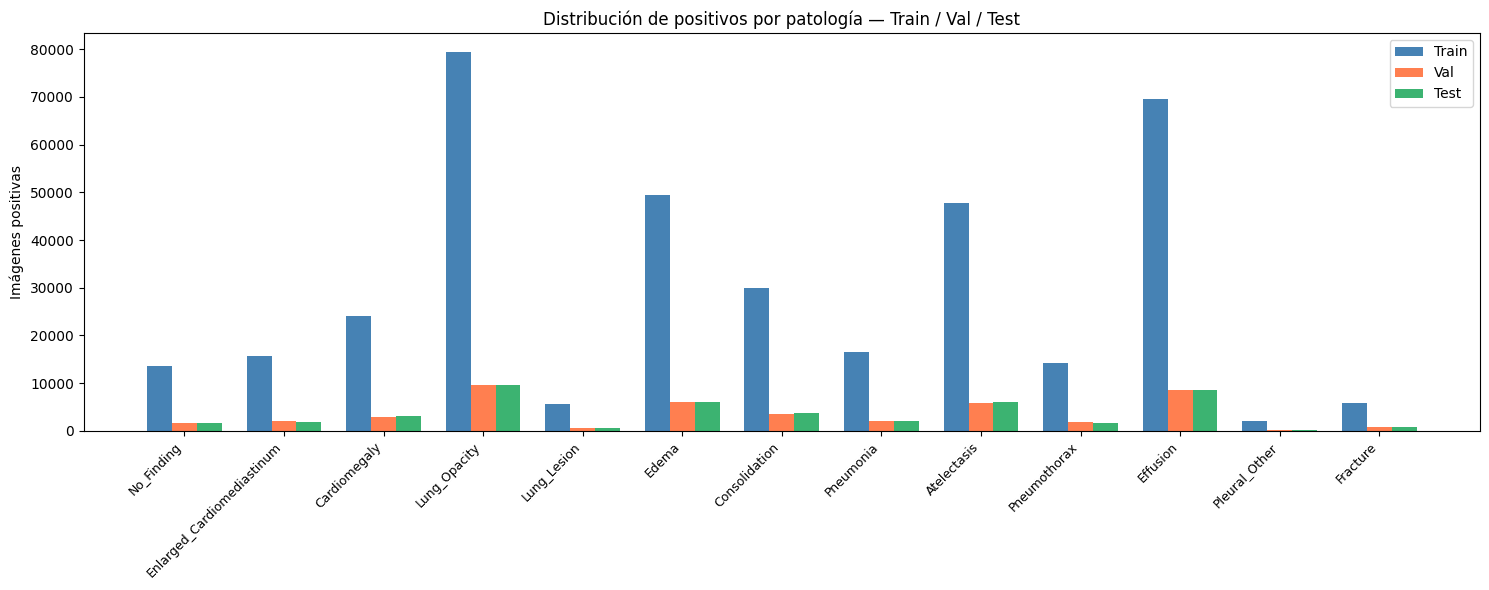

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 241MB/s]


Device: cuda

--- Epoch 1/25 ---
  batch 100/1200 | loss 0.6532
  batch 200/1200 | loss 0.6273
  batch 300/1200 | loss 0.6090
  batch 400/1200 | loss 0.5815
  batch 500/1200 | loss 0.5627
  batch 600/1200 | loss 0.5486
  batch 700/1200 | loss 0.5313
  batch 800/1200 | loss 0.5230
  batch 900/1200 | loss 0.5019
  batch 1000/1200 | loss 0.5005
  batch 1100/1200 | loss 0.4910
  batch 1200/1200 | loss 0.4910

Label                           AUC     F1   Prec Recall
------------------------------------------------------------
No_Finding                    0.459  0.168  0.092  0.999
Enlarged_Cardiomediastinum    0.492  0.190  0.105  0.984
Cardiomegaly                  0.510  0.271  0.157  0.990
Lung_Opacity                  0.523  0.676  0.511  0.999
Lung_Lesion                   0.530  0.074  0.042  0.320
Edema                         0.562  0.487  0.324  0.980
Consolidation                 0.504  0.322  0.192  0.996
Pneumonia                     0.515  0.199  0.111  0.962
Atelectasis      

In [ ]:
all_results = {}
for name, config in EXPERIMENTS.items():
    print(f"\n{'='*50}")
    print(f"Experimento: {name}")
    print(f"{'='*50}")
    all_results[name] = run_experiment(config, chexpert_train, chexpert_val, chexpert_test)

# Comparar
print(f"\n{'Experimento':<30} {'AUC':>8} {'F1':>8}")
print("-" * 48)
for name, res in all_results.items():
    print(f"{name:<30} {res['auc']:>8.4f} {res['f1']:>8.4f}")


# Carga de modelo

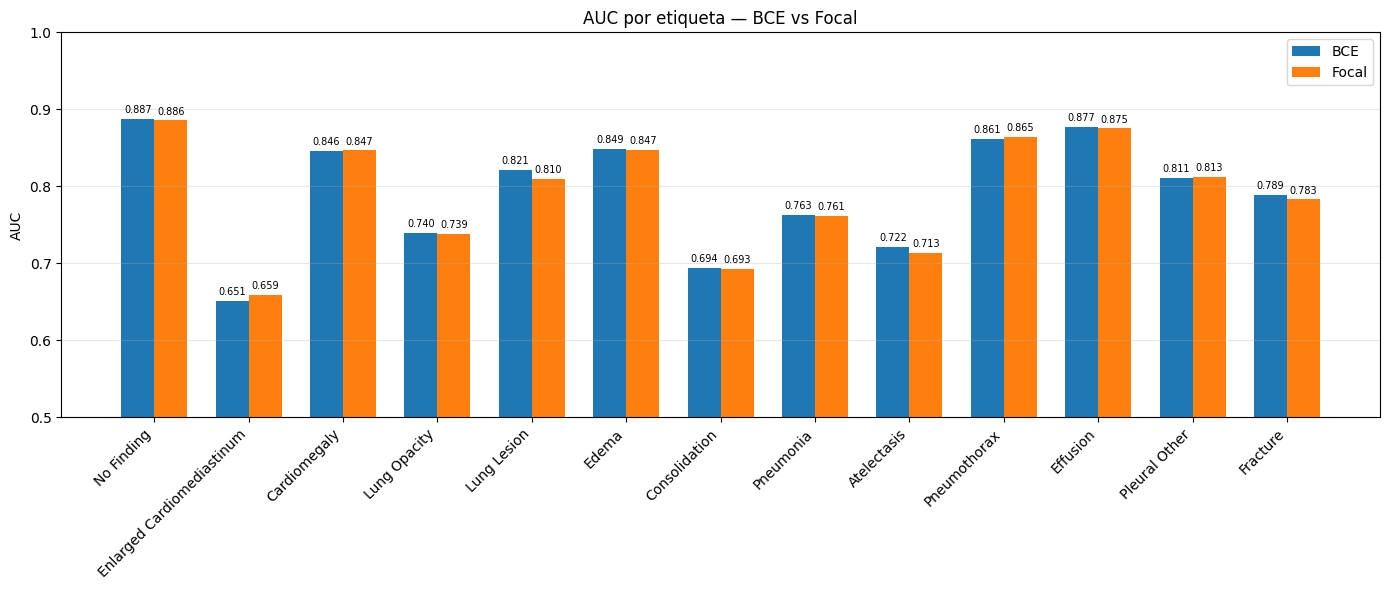

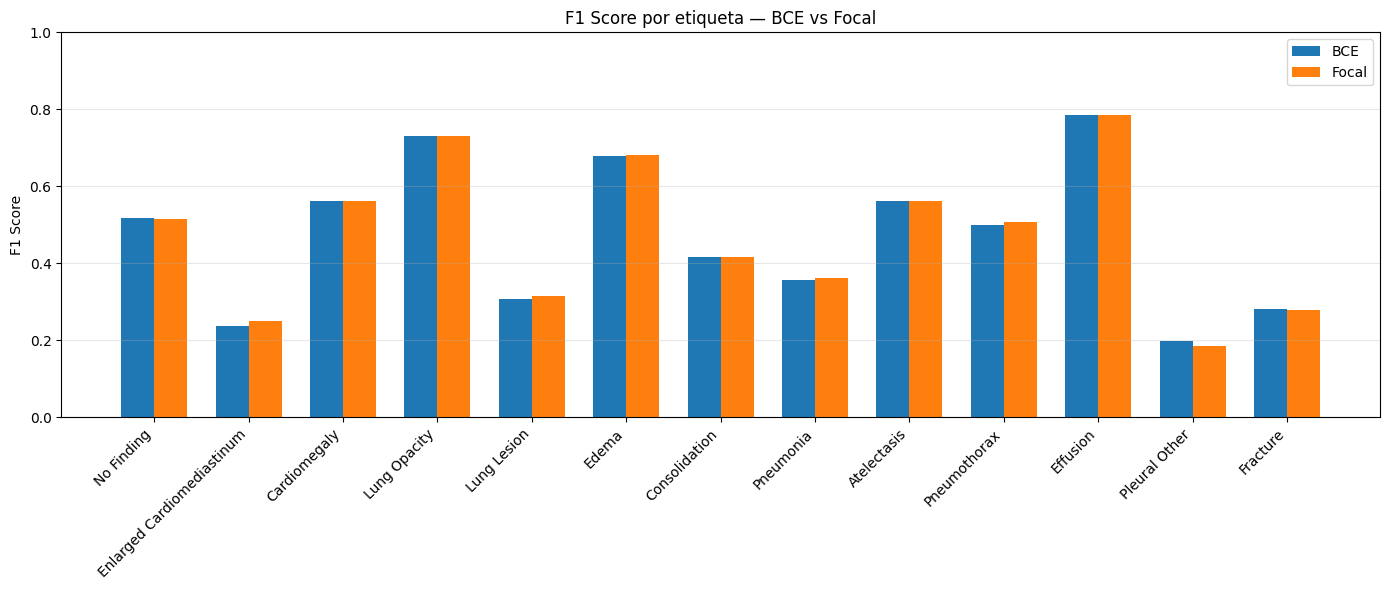

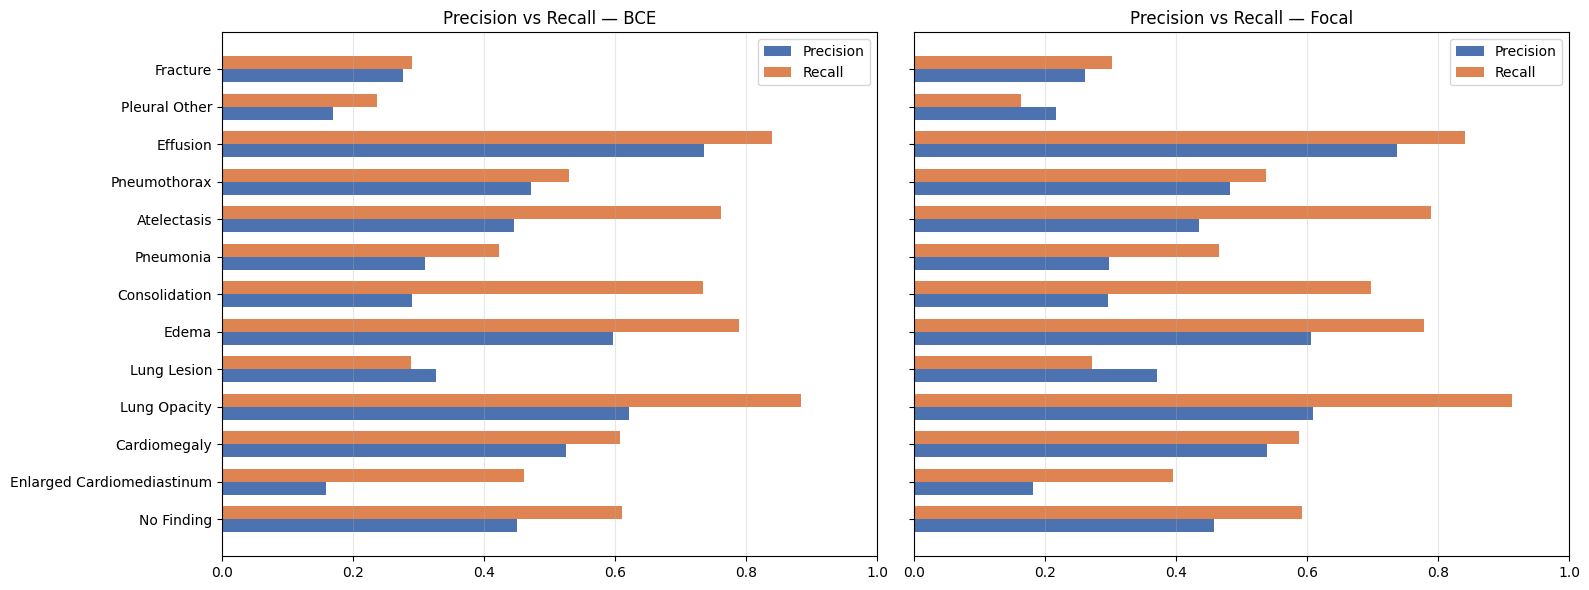

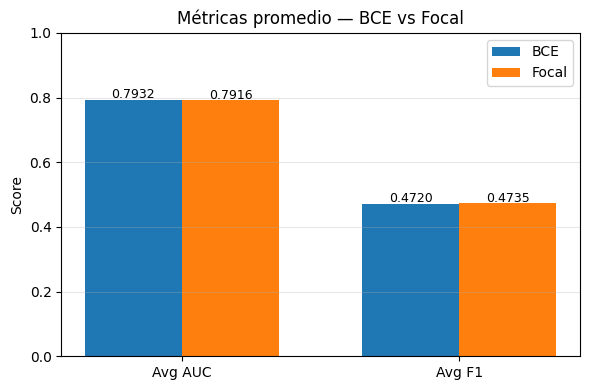

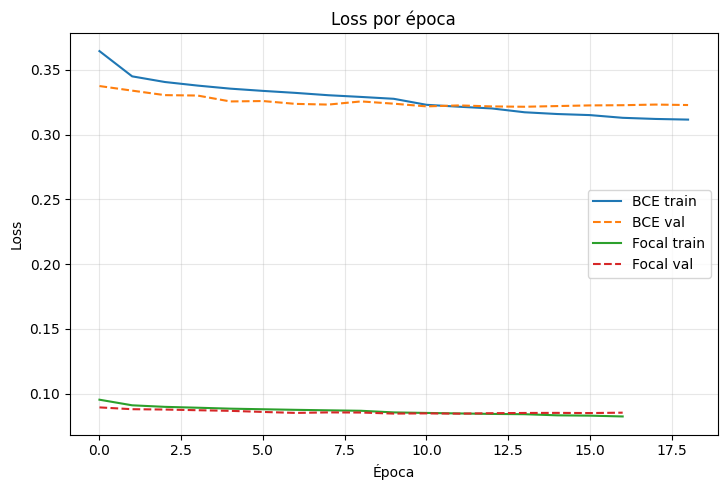

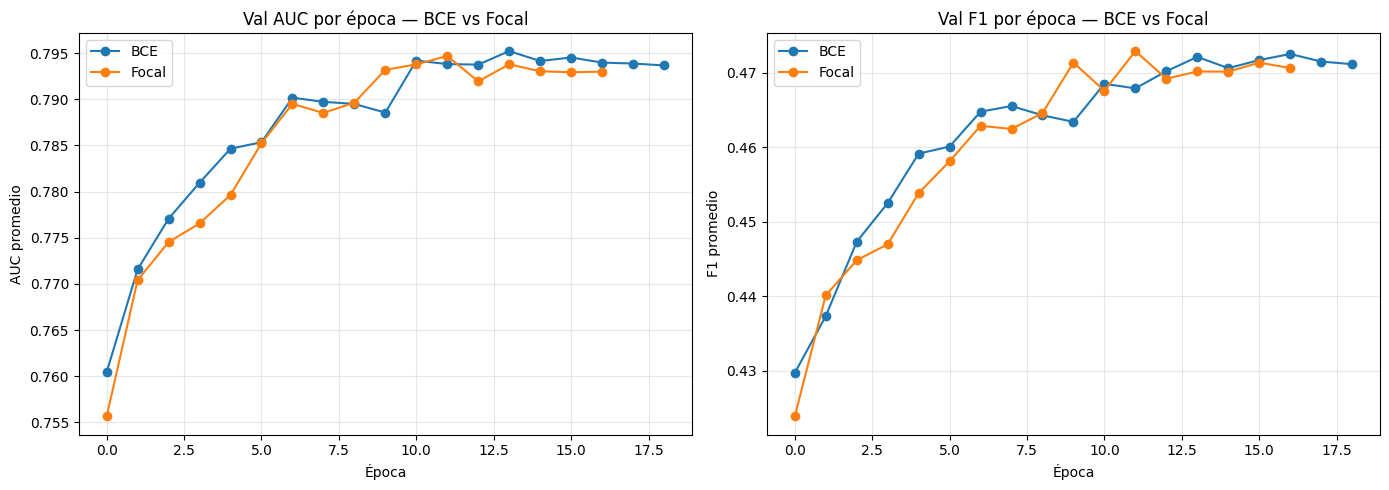

In [ ]:
import os, json
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = "/content/drive/MyDrive/PF-NN/resultados-final"

# --- Cargar todos los archivos ---
def load_json(name):
    with open(os.path.join(OUTPUT_DIR, name)) as f:
        return json.load(f)

bce_test    = load_json("densenet_bce_moderate_test_metrics.json")
focal_test  = load_json("densenet_focal_moderate_test_metrics.json")
bce_hist    = load_json("densenet_bce_moderate_history.json")
focal_hist  = load_json("densenet_focal_moderate_history.json")

models = {"BCE": bce_test, "Focal": focal_test}
histories = {"BCE": bce_hist, "Focal": focal_hist}
labels = list(bce_test["per_label"].keys())
labels_short = [l.replace("_", " ") for l in labels]

# =============================================
# 1. AUC por etiqueta — comparación BCE vs Focal
# =============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels))
w = 0.35

for i, (name, data) in enumerate(models.items()):
    aucs = [data["per_label"][l]["auc"] for l in labels]
    bars = ax.bar(x + i * w, aucs, w, label=name)
    for bar, v in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_ylabel("AUC")
ax.set_title("AUC por etiqueta — BCE vs Focal")
ax.set_xticks(x + w/2)
ax.set_xticklabels(labels_short, rotation=45, ha="right")
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 2. F1 Score por etiqueta
# =============================================
fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, data) in enumerate(models.items()):
    f1s = [data["per_label"][l]["f1"] for l in labels]
    ax.bar(x + i * w, f1s, w, label=name)

ax.set_ylabel("F1 Score")
ax.set_title("F1 Score por etiqueta — BCE vs Focal")
ax.set_xticks(x + w/2)
ax.set_xticklabels(labels_short, rotation=45, ha="right")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 3. Precision vs Recall por etiqueta
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, (name, data) in zip(axes, models.items()):
    prec = [data["per_label"][l]["precision"] for l in labels]
    rec  = [data["per_label"][l]["recall"] for l in labels]
    ax.barh(x - w/2, prec, w, label="Precision", color="#4C72B0")
    ax.barh(x + w/2, rec, w, label="Recall", color="#DD8452")
    ax.set_yticks(x)
    ax.set_yticklabels(labels_short)
    ax.set_title(f"Precision vs Recall — {name}")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 4. Resumen: Avg AUC y Avg F1
# =============================================
fig, ax = plt.subplots(figsize=(6, 4))
metrics_names = ["Avg AUC", "Avg F1"]
bce_vals  = [bce_test["avg_auc"], bce_test["avg_f1"]]
focal_vals = [focal_test["avg_auc"], focal_test["avg_f1"]]
x2 = np.arange(len(metrics_names))

bars1 = ax.bar(x2 - w/2, bce_vals, w, label="BCE")
bars2 = ax.bar(x2 + w/2, focal_vals, w, label="Focal")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.4f}", ha="center", fontsize=9)

ax.set_ylabel("Score")
ax.set_title("Métricas promedio — BCE vs Focal")
ax.set_xticks(x2)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# 5. Curvas de entrenamiento (history) — Loss
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories.items():
    if "train_loss" in hist:
        axes[0].plot(hist["train_loss"], label=f"{name} train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], "--", label=f"{name} val")

axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dejar el segundo subplot vacío o eliminarlo si no tenés train_auc
axes[1].set_visible(False)

plt.tight_layout()
plt.show()

# =============================================
# 6. Val AUC y Val F1 por época — BCE vs Focal
# =============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories.items():
    if 'val_auc' in hist:
        ax1.plot(hist['val_auc'], marker='o', label=name)
    if 'val_f1' in hist:
        ax2.plot(hist['val_f1'], marker='o', label=name)

ax1.set_title('Val AUC por época — BCE vs Focal')
ax1.set_xlabel('Época')
ax1.set_ylabel('AUC promedio')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_title('Val F1 por época — BCE vs Focal')
ax2.set_xlabel('Época')
ax2.set_ylabel('F1 promedio')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

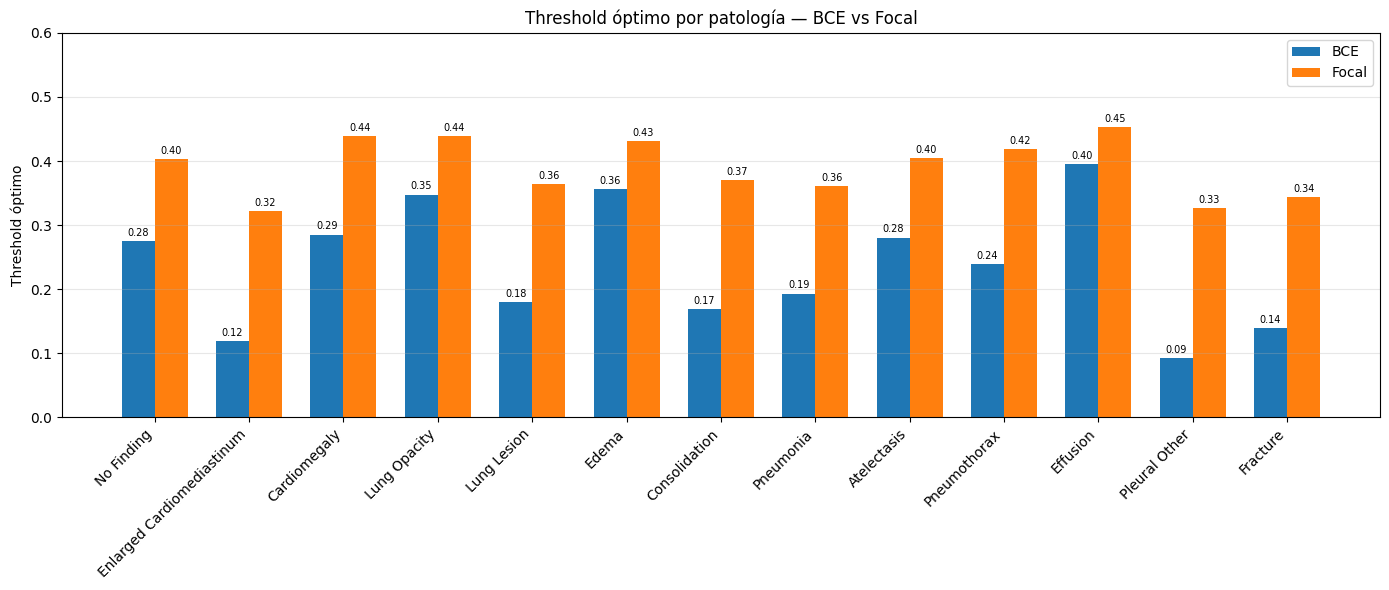

In [ ]:
# =============================================
# Threshold por etiqueta — BCE vs Focal
# =============================================
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(labels))
w = 0.35

for i, (name, data) in enumerate(models.items()):
    thresholds = [data["per_label"][l]["threshold"] for l in labels]
    bars = ax.bar(x + i * w, thresholds, w, label=name)
    for bar, v in zip(bars, thresholds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_ylabel("Threshold óptimo")
ax.set_title("Threshold óptimo por patología — BCE vs Focal")
ax.set_xticks(x + w/2)
ax.set_xticklabels(labels_short, rotation=45, ha="right")
ax.set_ylim(0, 0.6)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

runtime.unassign()

In [ ]:
!nvidia-smi

In [ ]:
!kill -9 1478